# What Distinguishes Paying Players From Non-Paying Players

**Product:** an online gaming player-behavior dataset (40,034 players).

**Product question:** which behavioral segments (engagement, genre, activity) are associated with purchase conversion — to understand which segments to target with monetization mechanics.

**Hypotheses:**
- H1: more engaged players (EngagementLevel = High) convert to purchase more often
- H2: conversion differs across game genres
- H3: paying players differ on behavioral metrics (sessions, level, achievements, playtime)

## 1. Load and inspect the data

In [11]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('/kaggle/input/datasets/rabieelkharoua/predict-online-gaming-behavior-dataset/online_gaming_behavior_dataset.csv')

print(df.shape)
df.isna().sum().sum()

(14745, 13)


1

In [4]:
display(df.head(), df.tail())

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
14740,23740,25,Female,USA,Sports,3.993184,0,Medium,4,63,95,18,Medium
14741,23741,46,Female,USA,RPG,15.450778,0,Medium,0,76,61,16,Low
14742,23742,34,Female,USA,Action,22.904606,0,Easy,11,73,52,23,Medium
14743,23743,47,Female,Other,RPG,20.918904,1,Easy,13,102,75,45,High
14744,23744,22,Male,Other,Strategy,6.519019,0,Medium,16,17,91,33,NaN


**40 034** rows, no missing values.

## 2. Baseline conversion rate

In [8]:
overall_rate = df['InGamePurchases'].mean()

print(f"Overall purchase rate: {overall_rate*100:.2f}%")

Overall purchase rate: 19.94%


## 3. H1 — conversion by engagement level

In [9]:
conv_by_eng = df.groupby('EngagementLevel')['InGamePurchases'].agg(['count','mean'])
conv_by_eng.columns = ['n','purchase_rate']
conv_by_eng = conv_by_eng.reindex(['Low','Medium','High'])

conv_by_eng

,n,purchase_rate
EngagementLevel,,
Low,3799,0.191893
Medium,7124,0.200309
High,3821,0.205182


In [10]:
ct = pd.crosstab(df['EngagementLevel'], df['InGamePurchases'])
chi2, p, dof, exp = stats.chi2_contingency(ct)
print(ct)
print(f"chi2={chi2:.2f}, p-value={p:.4f}")

InGamePurchases     0     1
EngagementLevel            
High             3037   784
Low              3070   729
Medium           5697  1427
chi2=2.18, p-value=0.3365


**p-value > 0.05 — H1 is not supported.** 

The gap between 19.7% and 20.6% looks like random noise rather than a systematic effect. This is visible below: the confidence intervals almost fully overlap.

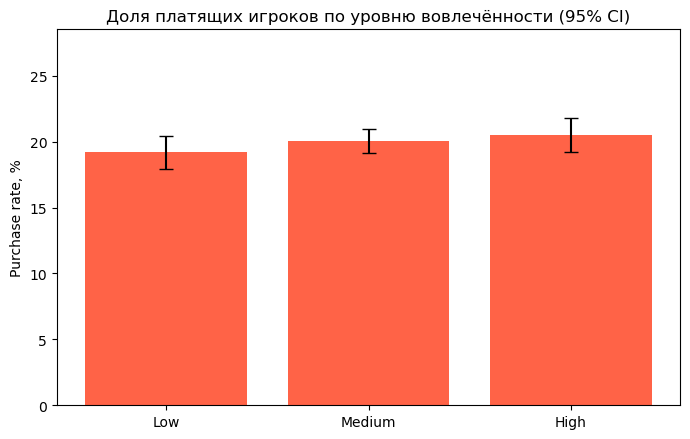

In [19]:
def prop_ci(x, n, z=1.96):
    p = x / n
    se = np.sqrt(p * (1 - p) / n)
    return p, z * se


fig, ax = plt.subplots(figsize=(7, 4.5))

order = ['Low', 'Medium', 'High']

vals, errs = [], []

for lvl in order:
    sub = df[df.EngagementLevel == lvl]
    p, err = prop_ci(sub.InGamePurchases.sum(), len(sub))
    vals.append(p * 100)
    errs.append(err * 100)

ax.bar(order, vals, yerr=errs, capsize=5, color='tomato')
ax.set_ylabel('Purchase rate, %')
ax.set_title('Доля платящих игроков по уровню вовлечённости (95% CI)')
ax.set_ylim(0, max(vals) + 8)

plt.tight_layout()
plt.show()

## 4. H2 — conversion by genre

In [20]:
conv_by_genre = df.groupby('GameGenre')['InGamePurchases'].agg(['count','mean']).sort_values('mean', ascending=False)
conv_by_genre.columns = ['n','purchase_rate']

conv_by_genre

,n,purchase_rate
GameGenre,,
Sports,3021,0.207547
Strategy,2934,0.207226
RPG,2957,0.206967
Simulation,2924,0.189466
Action,2909,0.185287


In [1]:
ct_genre = pd.crosstab(df['GameGenre'], df['InGamePurchases'])chi2_g, p_g, dof_g, exp_g = stats.chi2_contingency(ct_genre)print(f"chi2={chi2_g:.2f}, p-value={p_g:.4f}")

chi2=7.25, p-value=0.1233

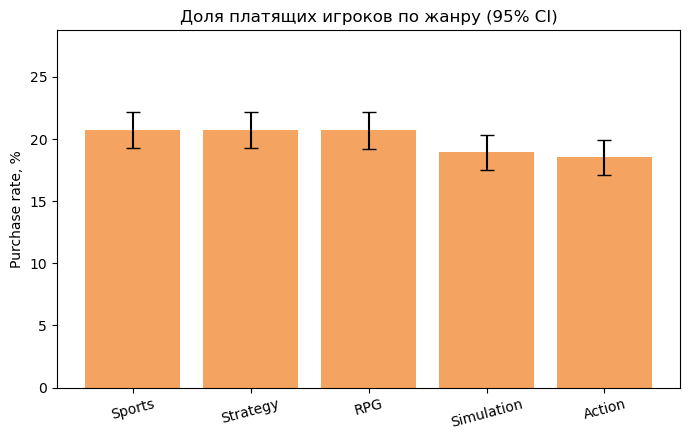

In [26]:
genre_order = (
    df.groupby('GameGenre')['InGamePurchases']
    .mean()
    .sort_values(ascending=False)
    .index
)

vals, errs = [], []

for g in genre_order:
    sub = df[df.GameGenre == g]
    p, err = prop_ci(sub.InGamePurchases.sum(), len(sub))
    vals.append(p * 100)
    errs.append(err * 100)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.bar(genre_order, vals, yerr=errs, capsize=5, color='sandybrown')
ax.set_ylabel('Purchase rate, %')
ax.set_title('Доля платящих игроков по жанру (95% CI)')
ax.set_ylim(0, max(vals) + 8)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**p = 0.123 (>0.05) — H2 is not supported either.** Genre is not significantly associated with conversion.

## 5. H3 — behavioral metrics: paying vs non-paying players

In [1]:
purch = df[df.InGamePurchases == 1]nonpurch = df[df.InGamePurchases == 0]metrics = ['SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'PlayTimeHours']for col in metrics:    t, p_t = stats.ttest_ind(purch[col], nonpurch[col], equal_var=False)    print(f"{col}: paying={purch[col].mean():.2f}, non-paying={nonpurch[col].mean():.2f}, p={p_t:.4f}")

SessionsPerWeek: paying=9.53, non-paying=9.46, p=0.3036AvgSessionDurationMinutes: paying=94.49, non-paying=94.87, p=0.5385PlayerLevel: paying=50.03, non-paying=49.56, p=0.1935AchievementsUnlocked: paying=24.53, non-paying=24.53, p=0.9845PlayTimeHours: paying=11.94, non-paying=12.05, p=0.2243

**All p-values are above 0.05 — H3 is not supported either.** None of the behavioral metrics differ significantly between paying and non-paying players.

## 6. Conclusion and recommendation**None of the three hypotheses were statistically supported:** engagement level, game genre, and behavioral metrics (sessions, playtime, level, achievements) show no significant association with purchase behavior (all p-values > 0.05).This is a meaningful, honest result rather than a "failed analysis" — in real product-analytics work, a large share of hypotheses don't hold up, and the job is to test them rigorously rather than force a significant story, so the product team doesn't invest in a segmentation that doesn't actually work.**Recommendation to the product team:** don't target monetization mechanics by engagement level or genre — in this data, neither predicts purchase behavior. Hypotheses should shift toward factors not captured in this dataset — e.g., the purchase flow itself (number of steps to checkout, presence of a "soft" first purchase, price anchoring) are more plausible levers for conversion than overall engagement..